# Mapping migration

## Set up

To get started on this notebook, you’ll need to restore any variables from previous notebooks to your workspace. To save time and memory, make sure to specify which variables you want to load.

In [1]:
%store -r

You will also need to import any libraries you are using in this notebook:

In [2]:
### import libraries

### import folder/file management
import os
import pathlib

### import for tabular data
import pandas as pd

### import for geo-vector data
import geopandas as gpd

### access gbif data for project (just in case)
import earthpy as et

## Step 4: Connect the GBIF observations to the ecoregions

### Step 4A: Identify the ecoregion for each observation

You can combine the ecoregions and the observations **spatially** using a method called `.sjoin()`, which stands for spatial join.

Check out the [`geopandas` documentation on spatial joins](https://geopandas.org/en/stable/docs/user_guide/mergingdata.html#spatial-joins) to learn more about spatial joins and how they work.

To perform your spatial join, you'll need to identify the correct values for the `how =` and `predicate =` parameters of the spatial join.

In [3]:
### join the gbif observations to the ecoregion polygons
gbif_ecoregion_gdf = (
    ecoreg_gdf
    
    ### match the CRS of the gbif data and the ecoregions
    .to_crs(gbif_gdf.crs)

    ### find ecoregion for each observation
    .sjoin(
        gbif_gdf,

        ### type of database join
        how = 'inner', 
        
        
        predicate = 'contains')

    ### any additional manipulations you want to do 
    ### (renaming columns, etc)
    [['OBJECTID', 'month']]

    ### rename columns for organization
    .rename(columns = {'OBJECTID': 'ecoregion'})
)

### check it out
gbif_ecoregion_gdf

,ecoregion,month
12,13.0,5
12,13.0,5
12,13.0,6
12,13.0,7
12,13.0,6
...,...,...
839,845.0,9
839,845.0,9
839,845.0,9
839,845.0,9


### Step 4B: Count the observations in each ecoregion each month

First, group the GBIF observations by ecoregion:
1. Replace `columns_to_group_by` with a list of columns. Keep in mind that you will end up with one row for each group – you want to count the observations in each ecoregion by month.
2. Select only month/ecoregion combinations that have more than one occurrence recorded, since a single occurrence could be an error.
3. Use the `.groupby()` and `.mean()` methods to compute the mean occurrences by ecoregion and by month.
4. Run the code – it will normalize the number of occurrences by month and ecoregion.

In [4]:
### summarize the occurrences by ecoregion/month combination
occurrence_df = (
    gbif_ecoregion_gdf

    ### group by each ecoregion and month 
    .groupby(['ecoregion', 'month'])

    ### and count the number of occurrences
    .agg(occurrences = ('ecoregion', 'count'))
)

### get rid of rare observations (which are possibly misidentifications)
occurrence_df = occurrence_df[occurrence_df.occurrences > 1]

### calculate the mean # observations by ecoregion
mean_occurrences_by_ecoregion = (
    occurrence_df
    .groupby('ecoregion')
    .mean()
)

### calculate the mean # observations by month
mean_occurrences_by_month = (
    occurrence_df
    .groupby('month')
    .mean()
)

### make sure everything looks right
mean_occurrences_by_month


,occurrences
month,
1,7.666667
2,7.333333
3,5.000000
4,143.527778
5,1226.186441
6,1089.048780
7,568.051282
8,167.567568
9,271.473684


### Step 4C: Normalize the observations

Divide occurrences by the mean occurrences by month and by ecoregion.

In [5]:
### normalize by space and time for sampling effort
occurrence_df['norm_occurrences'] = (
    occurrence_df
    / mean_occurrences_by_ecoregion
    / mean_occurrences_by_month
    
)

### check it out
occurrence_df

occurrences  norm_occurrences
ecoregion month                               
13.0      5                2          0.000816
          6                2          0.000918
          7                2          0.001760
17.0      4                2          0.000010
          5             3023          0.001701
...                      ...               ...
839.0     7              297          0.002202
          8               40          0.001006
          9               11          0.000171
845.0     9               28          0.005575
          10               9          0.014447

[309 rows x 2 columns]

<Axes: ylabel='Frequency'>

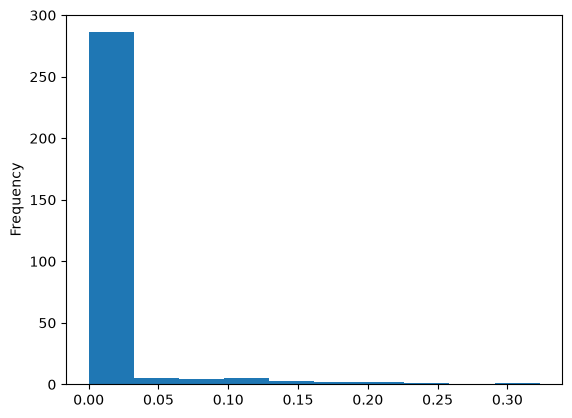

In [6]:
### histogram
occurrence_df.norm_occurrences.plot.hist()

<Axes: xlabel='month', ylabel='occurrences'>

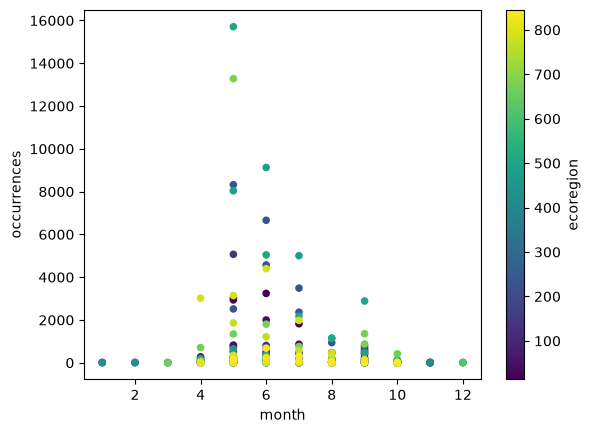

In [7]:
### scatterplot
occurrence_df.reset_index().plot.scatter(
    x = 'month',
    y = 'occurrences',
    c = 'ecoregion'
)

## Wrap up Step 4

Don’t forget to store your variables so you can use them in other notebooks! Replace `var1` and `var2` with the variable you want to save, separated by spaces.

In [8]:
%store occurrence_df

Stored 'occurrence_df' (DataFrame)


Finally, be sure to `Restart` and `Run all` to make sure your notebook
works all the way through!